# SAT Performance Analysis


## Problem Statement
This project analyzes the relationship between SAT participation rates and total SAT performance across NYC public schools. Using school-level average SAT scores and participation data, the analysis explores whether higher performance is associated with selective testing or broader student participation, and how this relationship varies across boroughs.
## Primary Question
How does SAT participation rate relate to total SAT performance across schools? 
### Secondary Question
Does this relationship differ by borough?

## Data Description
The unit of analysis is school. The schools can be categorised by boroughs. The SAT scores are school-level averages for math, reading and writing. Participation rates vary widely accross schools. Analysis shows association not causation. 


In [2]:

import pandas as pd
import matplotlib.pyplot as plt

schools = pd.read_csv("data/sat_data.csv")

schools.head()


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


## Data Cleaning
Total SAT score column was created by taking the sum of average math, reading and writing scores. 
Rows containing NA values for percent tested were removed.

In [3]:
schools['total_SAT'] = schools['average_math']+schools['average_reading']+schools['average_writing']


In [4]:
schools['percent_tested'].isna().mean()
schools[schools['percent_tested'].isna()]['borough'].value_counts()
schools = schools.dropna(subset=["percent_tested"])

## Analysis 1: Participation vs SAT Performance

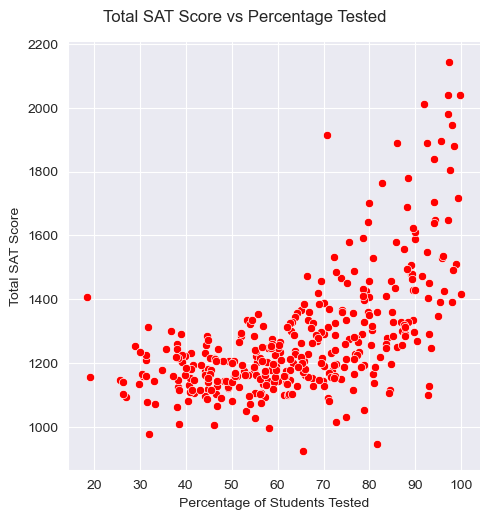

In [5]:
import seaborn as sns
sns.set_style('darkgrid')
g = sns.relplot(x='percent_tested', y='total_SAT', data=schools, kind='scatter' ,color='red')
g.figure.suptitle('Total SAT Score vs Percentage Tested', y=1.03)
g.set(xlabel = 'Percentage of Students Tested', ylabel = 'Total SAT Score')

The scatter plot shows a positive relationship between the percentage of students tested and total SAT scores. Schools with higher testing participation tend to have higher SAT scores suggesting that the stronger performing schools tend to have broader participation rather than selective testing.

## Analysis 2: Borough-wise Differences

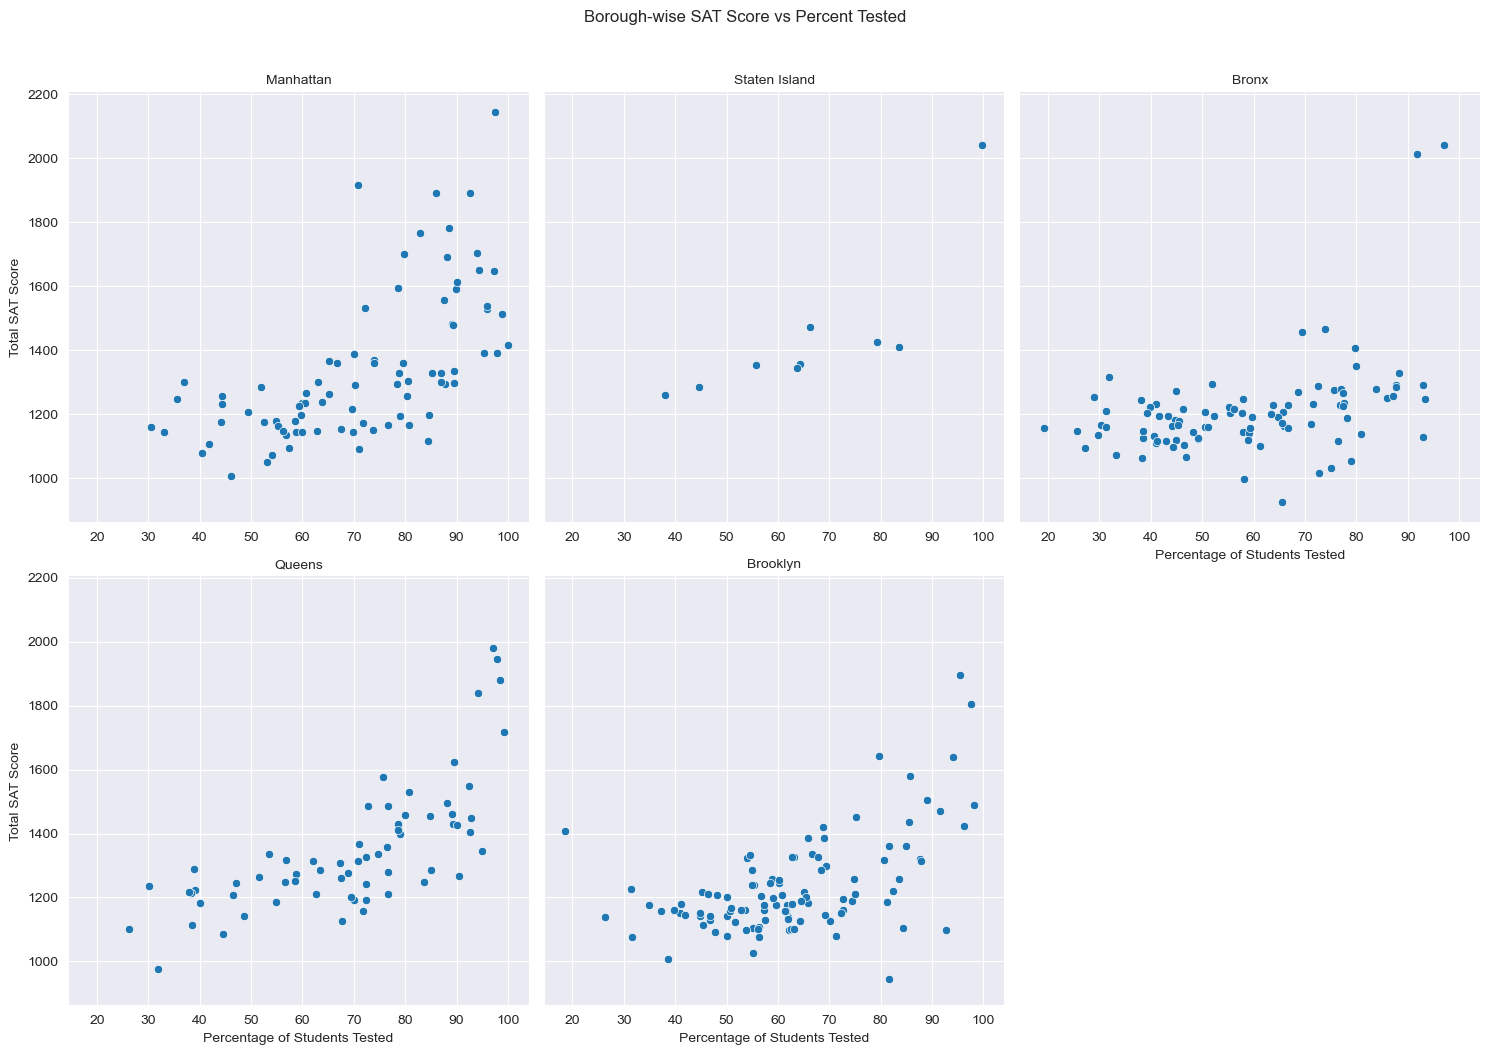

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(x='percent_tested', y='total_SAT', data=schools, kind='scatter', col = 'borough',col_wrap = 3)
g.figure.suptitle('Borough-wise SAT Score vs Percent Tested', y= 1.05)
g.set_titles('{col_name}')
g.set(xlabel = 'Percentage of Students Tested', ylabel = 'Total SAT Score')
for ax in g.axes.flat:   # if using seaborn FacetGrid
    ax.tick_params(axis='x', labelbottom=True)

The positive relationship observed in the overall plot is not uniform across boroughs. In Queens, the consistent upward trend indicates a stable relationship between higher participation and higher SAT performance across schools. In Manhattan, while higher participation is associated with better performance, the spread suggests differences in school-level outcomes even among high-participation schools.

In Brooklyn, although a positive relationship is still visible, there is greater dispersion in SAT scores across different participation levels. The variability indicates mixed performance levels across schools, even at similar participation rates.

In the Bronx, there is only a slight increase in SAT scores as participation rises, with most schools clustered within a narrower score range. Limited variation in performance suggests that participation changes have a smaller impact on overall score differences.

Staten Island shows an upward trend between participation and SAT scores; however, the number of schools represented is small, making it difficult to draw strong conclusions.

Overall, the borough-wise analysis suggests that school performance patterns differ across boroughs, and the positive relationship seen in the aggregated data is likely influenced by stronger-performing schools concentrated in certain areas.

# Conclusion

Higher SAT participation is generally associated with higher total SAT performance across NYC schools. The variability across boroughs indicates that participation rates alone do not account for performance differences. These patterns point to underlying structural differences in school-level performance across boroughs.
